In [ ]:
!huggingface-cli download openai-community/gpt2 \
    --local-dir ./gpt2 \
    --include "*.safetensors" "*.json" "*.txt" --exclude "/onnx/*"

⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
Fetching 14 files:   0% 0/14 [00:00<?, ?it/s]Downloading 'model.safetensors' to 'gpt2/.cache/huggingface/download/xGOKKLRSlIhH692hSVvI1-gpoa8=.248dfc3911869ec493c76e65bf2fcf7f615828b0254c12b473182f0f81d3a707.incomplete'

generation_config.json: 100% 124/124 [00:00<00:00, 603kB/s]

config.json:   0% 0.00/665 [00:00<?, ?B/s]Downloading 'merges.txt' to 'gpt2/.cache/huggingface/download/PtHk0z_I45atnj23IIRhTExwT3w=.226b0752cac7789c48f0cb3ec53eda48b7be36cc.incomplete'
config.json: 100% 665/665 [00:00<00:00, 5.76MB/s]
Download complete. Moving file to gpt2/config.json
Download complete. Moving file to gpt2/generation_config.json

config.json: 100% 879/879 [00:00<00:00, 7.24MB/s]
Fetching 14 files:   7% 1/14 [00:00<00:01,  6.70it/s]
merges.txt: 0.00B [00:00, ?B/s]Download complete. Moving file to gpt2/onnx/config.json


generation_config.json: 100% 119/119 [00:00<00:00, 1.14MB/s]
Download complete. Moving file t

In [ ]:
import torch

# 텐서 X에 대해 per-channel 양자화 및 복원 수행
def per_channel_quantize(X, axis=0):
    # 1. 채널별 최대 절댓값 기준으로 스케일 계산
    #    예: axis=0이면 열 단위로 max(abs(x)) 계산하여 shape 유지
    scale = 127 / torch.max(torch.abs(X), dim=axis, keepdim=True)[0]

    # 2. 스케일을 곱한 뒤 반올림하여 정수화 (양자화)
    X_quant = (scale * X).round()

    # 3. 양자화된 값을 스케일로 나누어 원래 범위로 복원 (디양자화)
    X_dequant = X_quant / scale

    # 4. 결과를 int8로 변환하여 반환
    return X_quant.to(torch.int8), X_dequant


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# 랜덤 시드 고정 (생성 결과 재현성 확보)
torch.manual_seed(0)

# 모델 연산에 사용할 디바이스 설정 (여기서는 GPU)
device = 'cuda'

# 사용할 모델 ID 설정 (GPT-2 모델)
model_id = '/content/gpt2'

# 사전학습된 causal language model(GPT-2) 로드 후 GPU로 이동
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

# 해당 모델에 맞는 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 모델의 전체 파라미터가 차지하는 GPU 메모리 크기 출력
print(f"Model size: {model.get_memory_footprint():,} bytes")


Model size: 510,342,192 bytes


In [ ]:
# 첫 번째 Transformer 블록의 self-attention projection (c_attn) 가중치 추출
weights = model.transformer.h[0].attn.c_attn.weight.data
print("Original weights:")
print(weights)

# 추출한 가중치에 대해 per-channel 양자화 적용
weights_per_channel_quant, _ = per_channel_quantize(weights)

# 양자화된 결과 출력 (int8 값)
print("\nPer Channel quantized weights:")
print(weights_per_channel_quant)


Original weights:
tensor([[-0.4738, -0.2614, -0.0978,  ...,  0.0513, -0.0584,  0.0250],
        [ 0.0874,  0.1473,  0.2387,  ..., -0.0525, -0.0113, -0.0156],
        [ 0.0039,  0.0695,  0.3668,  ...,  0.1143,  0.0363, -0.0318],
        ...,
        [-0.2592, -0.0164,  0.1991,  ...,  0.0095, -0.0516,  0.0319],
        [ 0.1517,  0.2170,  0.1043,  ...,  0.0293, -0.0429, -0.0475],
        [-0.4100, -0.1924, -0.2400,  ..., -0.0046,  0.0070,  0.0198]],
       device='cuda:0')

Per Channel quantized weights:
tensor([[-65, -38, -15,  ...,  20, -37,  12],
        [ 12,  21,  36,  ..., -20,  -7,  -7],
        [  1,  10,  55,  ...,  44,  23, -15],
        ...,
        [-36,  -2,  30,  ...,   4, -33,  15],
        [ 21,  31,  16,  ...,  11, -27, -22],
        [-56, -28, -36,  ...,  -2,   4,   9]], device='cuda:0',
       dtype=torch.int8)


In [ ]:
import numpy as np
from copy import deepcopy

# 원본 모델의 가중치 백업 (향후 비교를 위해)
weights = [param.data.clone() for param in model.parameters()]

# per-channel 양자화를 적용할 모델 복사본 생성
model_per_channel = deepcopy(model)

# 모든 파라미터에 대해 per-channel 양자화 적용
weights_per_channel = []
for param in model_per_channel.parameters():
    _, dequantized = per_channel_quantize(param.data)  # 양자화 후 디양자화된 값 사용
    param.data = dequantized                           # 디양자화된 값을 모델 파라미터에 덮어쓰기
    weights_per_channel.append(dequantized)            # 결과 저장


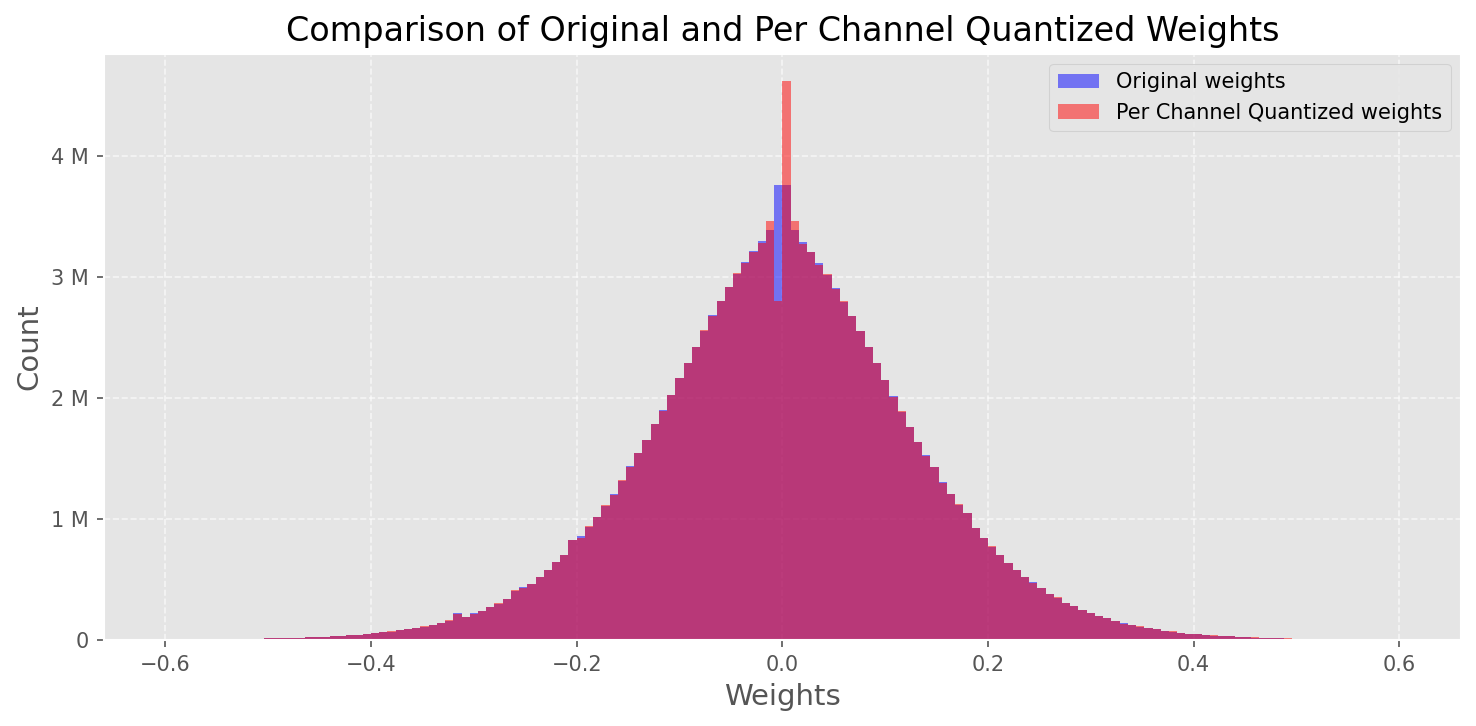

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 모든 파라미터 텐서를 1D로 평탄화한 후 하나의 numpy 배열로 연결
weights = np.concatenate([t.cpu().numpy().flatten() for t in weights])
weights_per_channel = np.concatenate([t.cpu().numpy().flatten() for t in weights_per_channel])

# 시각화 스타일 설정
plt.style.use('ggplot')

# 시각화 캔버스 및 축 생성
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# 원본 float32 가중치 분포 시각화
ax.hist(weights, bins=150, alpha=0.5, label='Original weights',
        color='blue', range=(-0.6, 0.6))

# per-channel 양자화 후 디양자화된 가중치 분포 시각화
ax.hist(weights_per_channel, bins=150, alpha=0.5, label='Per Channel Quantized weights',
        color='red', range=(-0.6, 0.6))

# 범례 추가
ax.legend()

# 그리드 추가
ax.grid(True, linestyle='--', alpha=0.6)

# 제목 및 축 레이블 설정
ax.set_title('Comparison of Original and Per Channel Quantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# y축 눈금 포맷을 사람 친화적으로 (예: 1K, 10K 등)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# 기본 폰트 크기 조정
plt.rc('font', size=12)

# 여백 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()

In [ ]:
# 텍스트를 생성하는 함수 정의
def generate_text(model, input_text, max_length=50):
    # 입력 문장을 토크나이즈하여 텐서로 변환하고 디바이스로 이동
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)

    # 모델을 이용해 토큰 시퀀스 생성 (샘플링 기반)
    output = model.generate(
        inputs=input_ids,
        max_length=max_length,                       # 생성할 최대 길이
        do_sample=True,                              # 확률적 샘플링 사용
        top_k=30,                                    # 확률 상위 30개에서만 샘플
        pad_token_id=tokenizer.eos_token_id,         # 패딩 토큰 ID 지정
        attention_mask=input_ids.new_ones(input_ids.shape)  # 모든 토큰에 attention 적용
    )

    # 생성된 토큰 시퀀스를 문자열로 디코딩 (특수 토큰 제거)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# 원본 모델과 per-channel 양자화 모델을 사용하여 텍스트 생성
original_text = generate_text(model, "I have a dream")
per_channel_text = generate_text(model_per_channel, "I have a dream")

# 결과 출력
print(f"Original model:\n{original_text}")
print("-" * 50)
print(f"Per Channel model:\n{per_channel_text}")


Original model:
I have a dream. I don't know what will come of it, but I am going to have to look for something that will be right. I haven't thought about it for a long time, but I have to try to get that thing
--------------------------------------------------
Per Channel model:
I have a dream job.

If you can't get your work done, you could be screwed right out of it... by the job you love.

I also have a dream... of having my dream job.

This is


In [ ]:
# 주어진 모델과 텍스트에 대해 perplexity(혼란도)를 계산하는 함수 정의
def calculate_perplexity(model, text):
    # 텍스트를 토크나이즈하여 입력 텐서 생성
    encodings = tokenizer(text, return_tensors='pt').to(device)

    # 입력 및 정답 시퀀스를 동일하게 설정 (자기 자신을 예측하도록)
    input_ids = encodings.input_ids
    target_ids = input_ids.clone()

    # 모델을 통해 손실 계산 (gradient 비활성화)
    with torch.no_grad():
        outputs = model(input_ids, labels=target_ids)

    # cross-entropy 기반 손실 값 추출
    neg_log_likelihood = outputs.loss

    # 손실값을 기반으로 perplexity 계산: perplexity = exp(loss)
    ppl = torch.exp(neg_log_likelihood)

    return ppl

# 원본 모델과 per-channel 양자화 모델에 대한 perplexity 계산
ppl = calculate_perplexity(model, original_text)
ppl_per_channel = calculate_perplexity(model_per_channel, per_channel_text)

# 결과 출력
print(f"Original perplexity: {ppl.item():.2f}")
print(f"Per Channel perplexity:   {ppl_per_channel.item():.2f}")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Original perplexity: 7.94
Per Channel perplexity:   14.23


In [ ]:
def per_group_quantization(X, num_groups, axis=0):
    num_channels = X.shape[axis]
    group_size = (num_channels + num_groups - 1) // num_groups

    # 그룹별 스케일 값을 먼저 1D로 생성 (채널 단위로 확장)
    expanded_scales = torch.empty(num_channels, device=X.device)

    for group_idx in range(num_groups):
        start = group_idx * group_size
        end = min((group_idx + 1) * group_size, num_channels)

        # 선택된 채널 인덱스에 대해 최대값 추출
        group = torch.index_select(X, axis, torch.arange(start, end, device=X.device))
        group_max = torch.max(torch.abs(group))

        scale = 127 / group_max if group_max > 0 else 1.0
        expanded_scales[start:end] = scale

    # 브로드캐스팅이 가능하도록 shape 변환 (예: [768, 1])
    scales_shape = [1] * X.dim()
    scales_shape[axis] = -1
    scales = expanded_scales.view(*scales_shape)

    # 양자화 및 디양자화
    X_quant = (scales * X).round()
    X_dequant = X_quant / scales

    return X_quant.to(torch.int8), X_dequant



In [ ]:
# 첫 번째 Transformer 블록의 self-attention projection (c_attn) 가중치 추출
weights = model.transformer.h[0].attn.c_attn.weight.data
print("Original weights:")
print(weights)

# 그룹 수 및 기준 축 설정 (예: 0번 축을 4개 그룹으로 나눔)
num_groups = 4
axis = 0

# 추출한 가중치에 대해 그룹 기반 양자화 적용
weights_per_channel_quant, _ = per_group_quantization(weights, num_groups=num_groups, axis=axis)

# 양자화된 결과 출력 (int8 값)
print("\nPer Channel quantized weights:")
print(weights_per_channel_quant)


Original weights:
tensor([[-0.4738, -0.2614, -0.0978,  ...,  0.0513, -0.0584,  0.0250],
        [ 0.0874,  0.1473,  0.2387,  ..., -0.0525, -0.0113, -0.0156],
        [ 0.0039,  0.0695,  0.3668,  ...,  0.1143,  0.0363, -0.0318],
        ...,
        [-0.2592, -0.0164,  0.1991,  ...,  0.0095, -0.0516,  0.0319],
        [ 0.1517,  0.2170,  0.1043,  ...,  0.0293, -0.0429, -0.0475],
        [-0.4100, -0.1924, -0.2400,  ..., -0.0046,  0.0070,  0.0198]],
       device='cuda:0')

Per Channel quantized weights:
tensor([[-28, -16,  -6,  ...,   3,  -3,   1],
        [  5,   9,  14,  ...,  -3,  -1,  -1],
        [  0,   4,  22,  ...,   7,   2,  -2],
        ...,
        [-13,  -1,  10,  ...,   0,  -3,   2],
        [  8,  11,   5,  ...,   1,  -2,  -2],
        [-20, -10, -12,  ...,   0,   0,   1]], device='cuda:0',
       dtype=torch.int8)


In [ ]:
import numpy as np
from copy import deepcopy

# 원본 모델의 가중치 저장 (나중에 비교 용도)
weights = [param.data.clone() for param in model.parameters()]

# 그룹 기반 양자화를 적용할 모델 복사본 생성
model_per_group = deepcopy(model)

# 그룹 수 및 기준 축 설정 (예: axis=0 → 채널 단위)
num_groups = 4
axis = 0

# 모든 파라미터에 대해 그룹 양자화 적용 및 복원값 저장
weights_per_group = []
for param in model_per_group.parameters():
    # 그룹 양자화 후 복원된 float32 값을 사용
    _, dequantized = per_group_quantization(param.data, num_groups=num_groups, axis=axis)
    param.data = dequantized                    # 모델 파라미터에 덮어쓰기
    weights_per_group.append(dequantized)       # 리스트에 저장


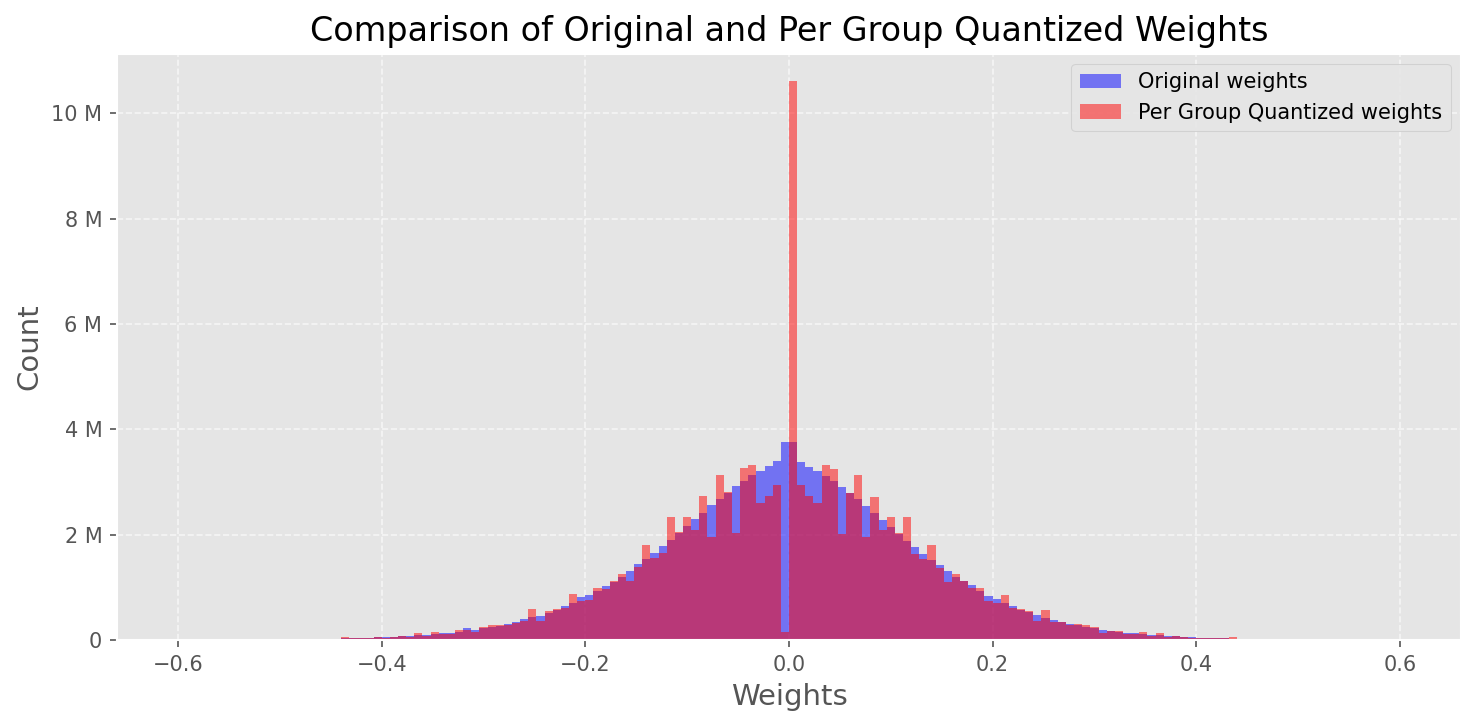

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 모든 가중치 텐서를 1D 배열로 평탄화하고 하나로 연결
weights = np.concatenate([t.cpu().numpy().flatten() for t in weights])
weights_per_group = np.concatenate([t.cpu().numpy().flatten() for t in weights_per_group])

# 시각화 스타일 설정
plt.style.use('ggplot')

# 시각화 캔버스 및 축 생성
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# 원본 float32 가중치 분포 시각화
ax.hist(weights, bins=150, alpha=0.5, label='Original weights',
        color='blue', range=(-0.6, 0.6))

# 그룹 기반 양자화 후 디양자화된 가중치 분포 시각화
ax.hist(weights_per_group, bins=150, alpha=0.5, label='Per Group Quantized weights',
        color='red', range=(-0.6, 0.6))

# 범례 추가
ax.legend()

# 그리드 추가
ax.grid(True, linestyle='--', alpha=0.6)

# 제목 및 축 레이블 설정
ax.set_title('Comparison of Original and Per Group Quantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# y축 눈금을 사람이 읽기 쉽게 포맷팅
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# 폰트 크기 설정
plt.rc('font', size=12)

# 여백 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()


In [ ]:
# 원본 모델과 per-group 양자화 모델을 사용하여 텍스트 생성
original_text = generate_text(model, "I have a dream")
per_group_text = generate_text(model_per_group, "I have a dream")

# 생성된 텍스트 결과 출력
print(f"Original model:\n{original_text}")
print("-" * 50)
print(f"Per Group model:\n{per_group_text}")


Original model:
I have a dream that I will go on to a good career on the front lines of World War II."

In the end, he would leave his family behind in Switzerland where he worked as an art designer. His wife's parents were born
--------------------------------------------------
Per Group model:
I have a dream of working for him, but I cannot do it without risking it. It must be resisted fiercely for my sake. I wish for me not to be robbed of my liberty, but my life is on hold, and my heart's


In [ ]:
# 원본 모델과 per-group 양자화 모델의 perplexity 계산
ppl = calculate_perplexity(model, original_text)
ppl_per_group = calculate_perplexity(model_per_group, per_group_text)

# 결과 출력
print(f"Original perplexity: {ppl.item():.2f}")
print(f"Per Group perplexity:   {ppl_per_group.item():.2f}")


Original perplexity: 13.68
Per Group perplexity:   21.62
